<a href="https://colab.research.google.com/github/shaikhdaiyaan251-cloud/CODE-ALPHA-DATA-SCIENCE-INTERNSHIP-TASK-3/blob/main/DATA_SCIENCE_INTERNSHIP_TASK_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 3: CAR PRICE PREDICTION**


## **3.1. Setting Up Colab Environment (Importing Necessary Libraries)**
 3.1.1 Install required packages (if not already present)

 3.1.2 Import libraries

 3.1.3 Set visualization styles

 3.1.4 Mount Google Drive (Optional/Handled)

 3.1.5 Set random seed

 3.1.6 Display environment info


## **3.2. Loading and Understanding the Dataset**
 3.2.1 Load the dataset (no Drive)

 3.2.2 Initial Data Inspection

 3.2.3 Check for Missing Values

 3.2.4 Identify Target Variable (Price)

 3.2.5 Identify Categorical and Numerical Columns

 3.2.6 Check for Duplicate Rows

 3.2.7 Display Basic Info about the Dataset

 3.2.8 Display first few rows with formatting


## **3.3. Performing Exploratory Data Analysis (EDA)**
 3.3.1 Distribution of Target Variable (Price)

 3.3.2 Correlation Heatmap (Numerical Features vs Price)

 3.3.3 Pairplot of Top Features (colored by a categorical variable if available)

 3.3.4 Categorical Features Impact on Price (Boxplots)

 3.3.5 Scatter Plots: Key Numerical Features vs Price (with Regression Line)

 3.3.6 Interactive 3D Scatter Plot (Plotly) – Extra Eye‑Catching

 3.3.7 Feature Importance Preview (using Random Forest – quick)

 3.3.8 Summary of EDA Insights


## **3.4. Data Preprocessing & Feature Engineering**
 3.4.1 Create a Copy of the Data

 3.4.2 Handle Missing Values

 3.4.3 Feature Engineering: Car Age (if 'year' column exists)

 3.4.4 Additional Feature Engineering (if applicable)

 3.4.5 Separate Features (X) and Target (y)

 3.4.6 Identify Updated Categorical and Numerical Columns

 3.4.7 Train-Test Split

 3.4.8 Preprocessing Pipelines (Scaling & Encoding)

 3.4.9 (Optional) Visualize Preprocessed Data Distribution

 3.4.10 Save Preprocessed Data (Optional)


## **3.5. Training Multiple Regression Models**
 3.5.1 Define Models to Train

 3.5.2 Train and Evaluate Each Model

 3.5.3 Display Results Summary

 3.5.4 Visual Comparison of Model Performance

 3.5.5 Detailed Evaluation of the Best Model

 3.5.6 Actual vs Predicted Scatter Plot (Best Model)

 3.5.7 Residual Plot (Best Model)

 3.5.8 Feature Importance (if tree-based model)

 3.5.9 Save the Best Model


## **3.6. Hyperparameter Tuning (Extra Effort)**
 3.6.1 Choose the Best Model Type from Previous Step

 3.6.2 Define Hyperparameter Grids

 3.6.3 Randomized Search (Faster) vs Grid Search (Exhaustive)

 3.6.4 (Optional) Grid Search on Reduced Parameter Space

 3.6.5 Evaluate Tuned Model on Test Set

 3.6.6 Compare with Untuned Baseline Model

 3.6.7 Visualize: Actual vs Predicted (Tuned Model)

 3.6.8 Residual Plot (Tuned Model)

 3.6.9 Feature Importance of Tuned Model

 3.6.10 Save the Tuned Model


## **3.7. Evaluating the Best Model**
 3.7.1 Cross-Validation (k-fold) on Training Set

 3.7.2 Test Set Performance Metrics

 3.7.3 Residual Analysis

 3.7.4 Learning Curves (Diagnose Bias/Variance)

 3.7.5 Feature Importance (Permutation Importance as alternative)

 3.7.6 Error Distribution by Price Segments (Optional)

 3.7.7 Summary Evaluation Report


## **3.8. Saving & Documenting Results**
 3.8.1 Save the Best Tuned Model

 3.8.2 Save Predictions on Test Set

 3.8.3 Save Evaluation Metrics (JSON)

 3.8.4 Generate README.md for GitHub (FIXED STRING)

 3.8.5 Zip and Download


## **3.1. Setting Up Colab Environment (Importing Necessary Libraries)**
 3.1.1 Install required packages (if not already present)

 3.1.2 Import libraries

 3.1.3 Set visualization styles

 3.1.4 Mount Google Drive (Optional/Handled)

 3.1.5 Set random seed

 3.1.6 Display environment info


In [ ]:
# ==================================================
# 3.1. Setting Up Your Colab Environment
# ==================================================

# ----------------------------
# 3.1.1 Install required packages (if not already present)
# ----------------------------
!pip install -q pandas numpy matplotlib seaborn plotly scikit-learn scipy statsmodels openpyxl joblib

# ----------------------------
# 3.1.2 Import libraries
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Import base sklearn for version checking
import sklearn

# Scikit-learn modules for preprocessing, modeling, evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Regression algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Additional utilities
from scipy import stats
import warnings
import os
import joblib
from datetime import datetime

# Suppress annoying warnings
warnings.filterwarnings('ignore')

# ----------------------------
# 3.1.3 Set visualization styles
# ----------------------------
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['savefig.dpi'] = 300

sns.set_theme(style='whitegrid', context='talk')
import plotly.io as pio
pio.templates.default = 'plotly_white'

# ----------------------------
# 3.1.4 Mount Google Drive (Optional/Handled)
# ----------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("Google Drive mounted at /content/drive")

    project_path = '/content/drive/MyDrive/CodeAlpha_Car_Price_Prediction'
    if not os.path.exists(project_path):
        os.makedirs(project_path)
        print(f"Created project folder: {project_path}")
except Exception as e:
    print(f"Drive mount skipped or failed: {e}")
    print("Using local directory for this session.")

# ----------------------------
# 3.1.5 Set random seed
# ----------------------------
np.random.seed(42)

# ----------------------------
# 3.1.6 Display environment info
# ----------------------------
print("\n" + "="*50)
print("Environment Ready!")
print("="*50)
print(f"Date & Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Plotly version: {plotly.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print("All libraries imported successfully.")
print("="*50)

Drive mount skipped or failed: Error: credential propagation was unsuccessful
Using local directory for this session.

Environment Ready!
Date & Time: 2026-05-04 16:03:31
Pandas version: 2.2.2
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Plotly version: 5.24.1
Scikit-learn version: 1.6.1
All libraries imported successfully.


## **3.2. Loading and Understanding the Dataset**
 3.2.1 Load the dataset (no Drive)

 3.2.2 Initial Data Inspection

 3.2.3 Check for Missing Values

 3.2.4 Identify Target Variable (Price)

 3.2.5 Identify Categorical and Numerical Columns

 3.2.6 Check for Duplicate Rows

 3.2.7 Display Basic Info about the Dataset

 3.2.8 Display first few rows with formatting


In [ ]:
# ==================================================
# 3.2. Load and Understand the Dataset (Car Price Prediction)
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# 3.2.1 Load the dataset (no Drive)
# ----------------------------
# Option A: Upload from local machine (recommended)
print("📂 Option A: Upload CSV from your computer")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"✅ Loaded {filename}")

# Option B: Load directly from a URL (uncomment and use actual URL)
# url = 'https://raw.githubusercontent.com/example/car_data.csv'
# df = pd.read_csv(url)
# print(f"✅ Loaded from URL: {url}")

# ----------------------------
# 3.2.2 Initial Data Inspection
# ----------------------------
print("\n" + "="*60)
print("📊 INITIAL DATA INSPECTION")
print("="*60)

print("\n🔍 First 5 rows:")
print(df.head())

print("\n🔍 Last 5 rows:")
print(df.tail())

print("\n📏 Dataset shape (rows, columns):")
print(df.shape)

print("\n📋 Column names:")
print(df.columns.tolist())

print("\nℹ️ Data types and non-null counts:")
print(df.info())

print("\n📈 Summary statistics (numerical columns):")
print(df.describe())

print("\n🎯 Summary statistics (all columns including categorical):")
print(df.describe(include='all'))

# ----------------------------
# 3.2.3 Check for Missing Values
# ----------------------------
print("\n" + "="*60)
print("🔍 MISSING VALUES ANALYSIS")
print("="*60)

missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
if missing_counts.sum() > 0:
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
    plt.title('Missing Values Heatmap', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found in the dataset!")

# ----------------------------
# 3.2.4 Identify Target Variable (Price)
# ----------------------------
# Common price column names in car datasets
price_keywords = ['price', 'selling_price', 'msrp', 'cost', 'amount', 'Price', 'Selling_Price']
target_col = None
for col in price_keywords:
    if col in df.columns:
        target_col = col
        break

if target_col:
    print(f"\n💰 Target variable (price) identified: '{target_col}'")
    print(f"   Price range: {df[target_col].min():.0f} to {df[target_col].max():.0f}")
    print(f"   Average price: {df[target_col].mean():.2f}")
else:
    print("\n⚠️ No obvious price column found. Please check column names manually.")

# ----------------------------
# 3.2.5 Identify Categorical and Numerical Columns
# ----------------------------
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\n" + "="*60)
print("📊 COLUMN CLASSIFICATION")
print("="*60)
print(f"\n🏷️ Categorical columns: {cat_cols}")
print(f"🔢 Numerical columns: {num_cols}")

# Remove target column from numerical features if present
if target_col and target_col in num_cols:
    num_cols.remove(target_col)
    print(f"\n🎯 Target column '{target_col}' removed from numerical features list.")

# Identify car‑specific categorical features (optional)
car_cat_keywords = ['fuel', 'transmission', 'seller', 'owner', 'brand', 'model', 'make']
car_cat_cols = [col for col in cat_cols if any(kw in col.lower() for kw in car_cat_keywords)]
if car_cat_cols:
    print(f"\n🚗 Likely car categorical features: {car_cat_cols}")

# ----------------------------
# 3.2.6 Check for Duplicate Rows
# ----------------------------
duplicates = df.duplicated().sum()
print(f"\n🔄 Duplicate rows: {duplicates}")
if duplicates > 0:
    print("⚠️ Duplicate rows found. Consider removing them in the cleaning step.")

# ----------------------------
# 3.2.7 Display Basic Info about the Dataset
# ----------------------------
print("\n" + "="*60)
print("📋 DATASET SUMMARY")
print("="*60)
print(f"Total Records: {len(df):,}")
print(f"Total Features: {len(df.columns)}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# ----------------------------
# 3.2.8 Display first few rows with formatting
# ----------------------------
print("\n" + "="*60)
print("📄 SAMPLE DATA (First 10 rows)")
print("="*60)
display(df.head(10))

📂 Option A: Upload CSV from your computer


Saving archive (7).zip to archive (7).zip
✅ Loaded archive (7).zip

📊 INITIAL DATA INSPECTION

🔍 First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

🔍 Last 5 rows:
    Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
296     city  2016           9.50           11.6       33988    Diesel   
297     brio  2015           4.00            5.9       60000    Petrol

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


## **3.3. Performing Exploratory Data Analysis (EDA)**
 3.3.1 Distribution of Target Variable (Price)

 3.3.2 Correlation Heatmap (Numerical Features vs Price)

 3.3.3 Pairplot of Top Features (colored by a categorical variable if available)

 3.3.4 Categorical Features Impact on Price (Boxplots)

 3.3.5 Scatter Plots: Key Numerical Features vs Price (with Regression Line)

 3.3.6 Interactive 3D Scatter Plot (Plotly) – Extra Eye‑Catching

 3.3.7 Feature Importance Preview (using Random Forest – quick)

 3.3.8 Summary of EDA Insights


📊 EXPLORATORY DATA ANALYSIS - CAR PRICE PREDICTION


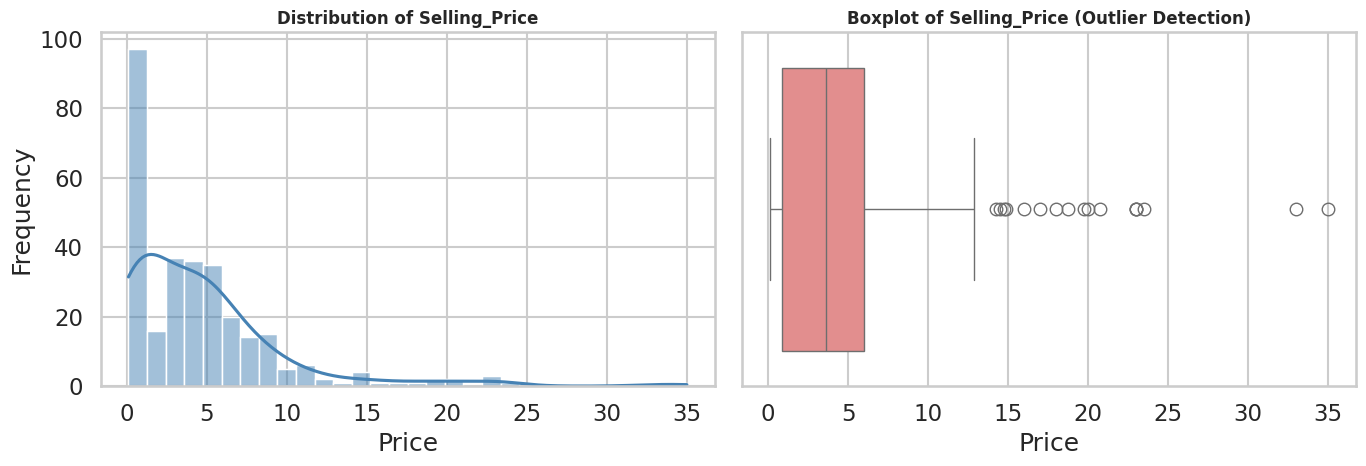


📈 Price distribution statistics:
   Skewness: 2.49 (right-skewed)
   Kurtosis: 8.90


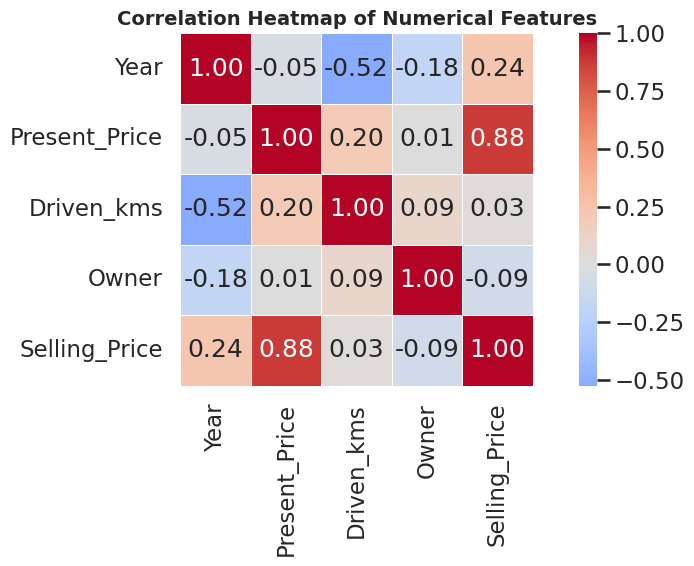


🔗 Top 3 features positively correlated with price:
   Present_Price: 0.879
   Year: 0.236
   Driven_kms: 0.029


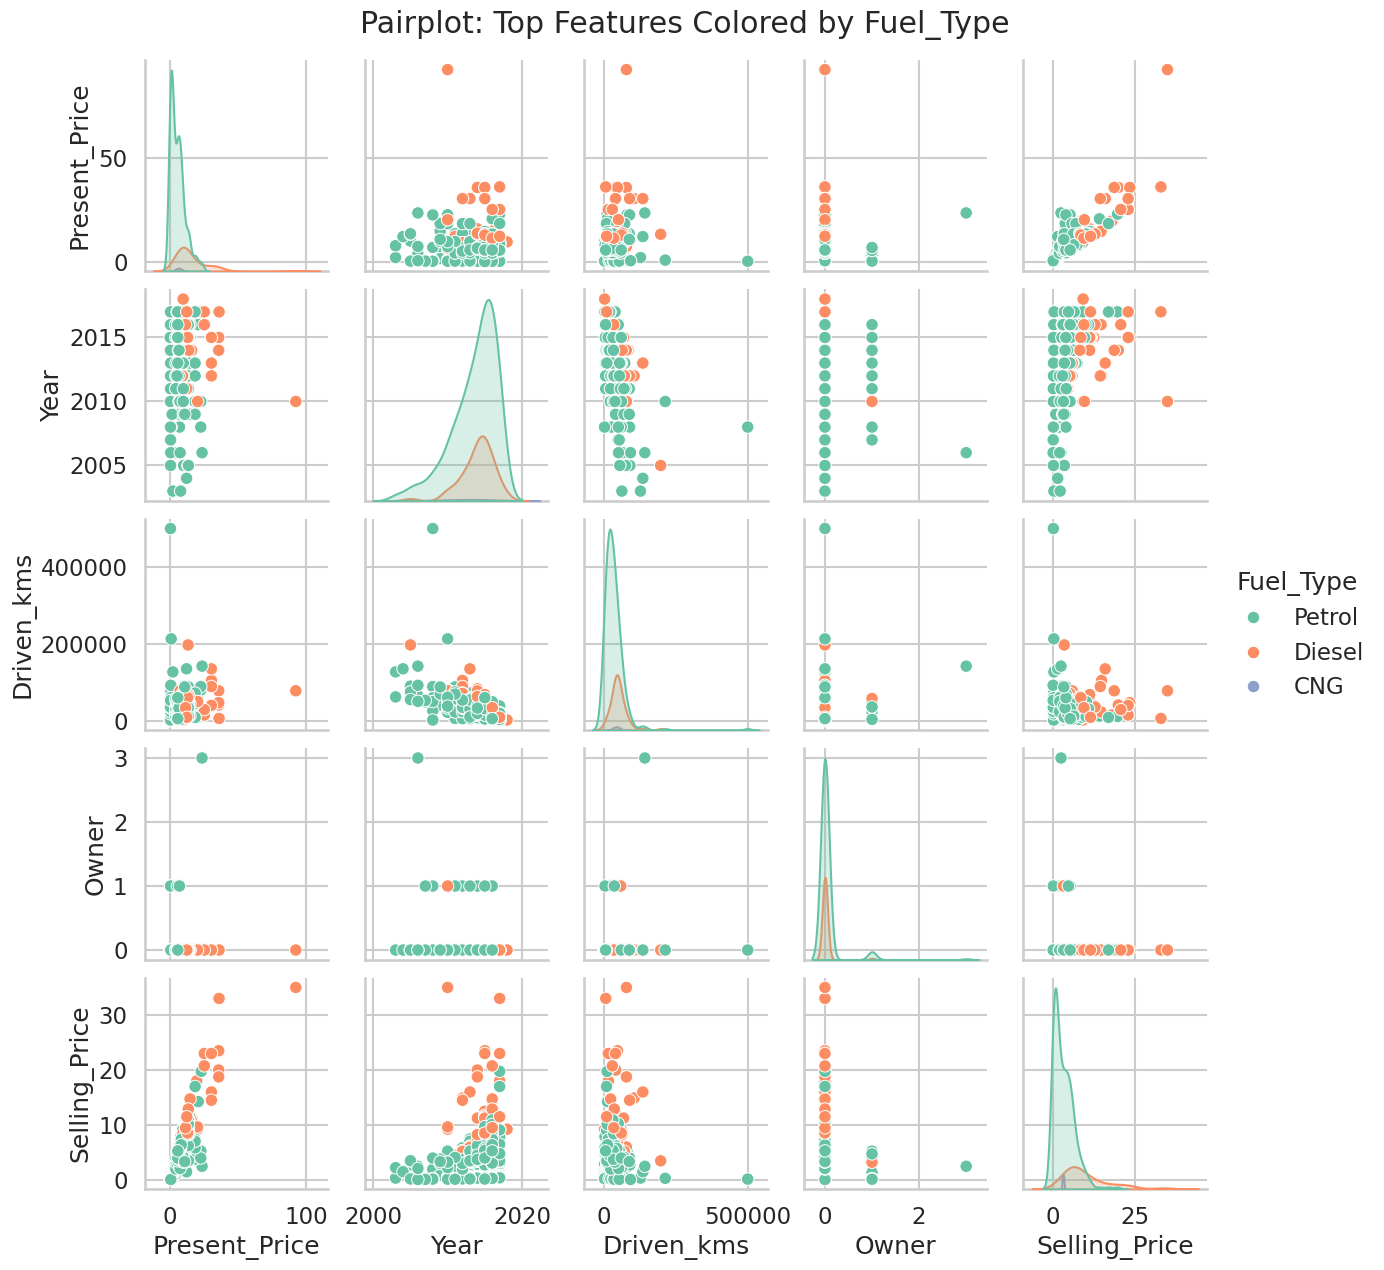

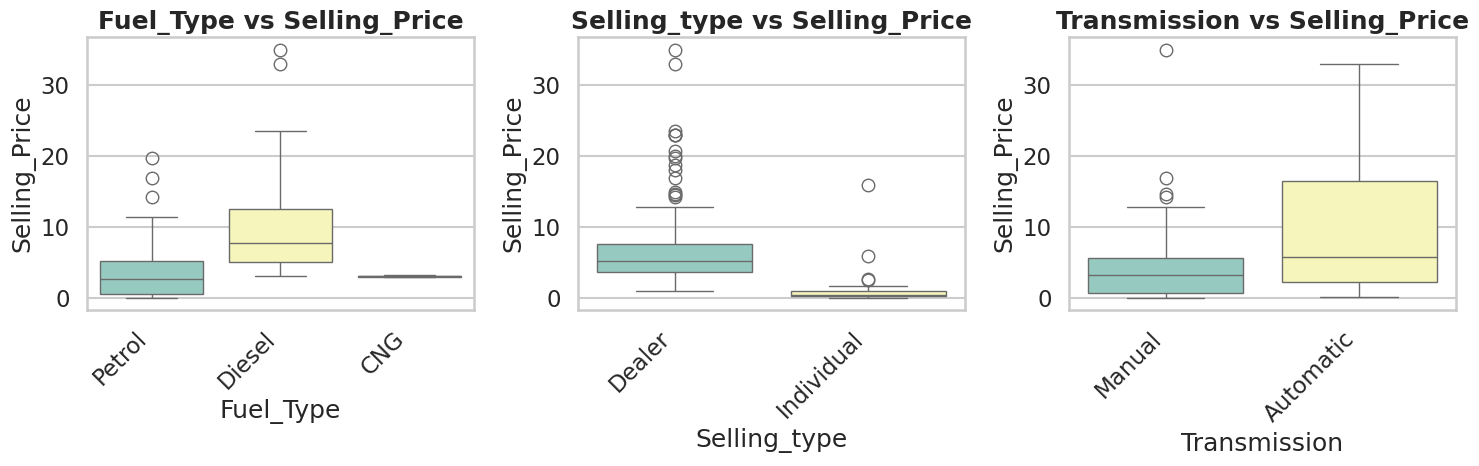

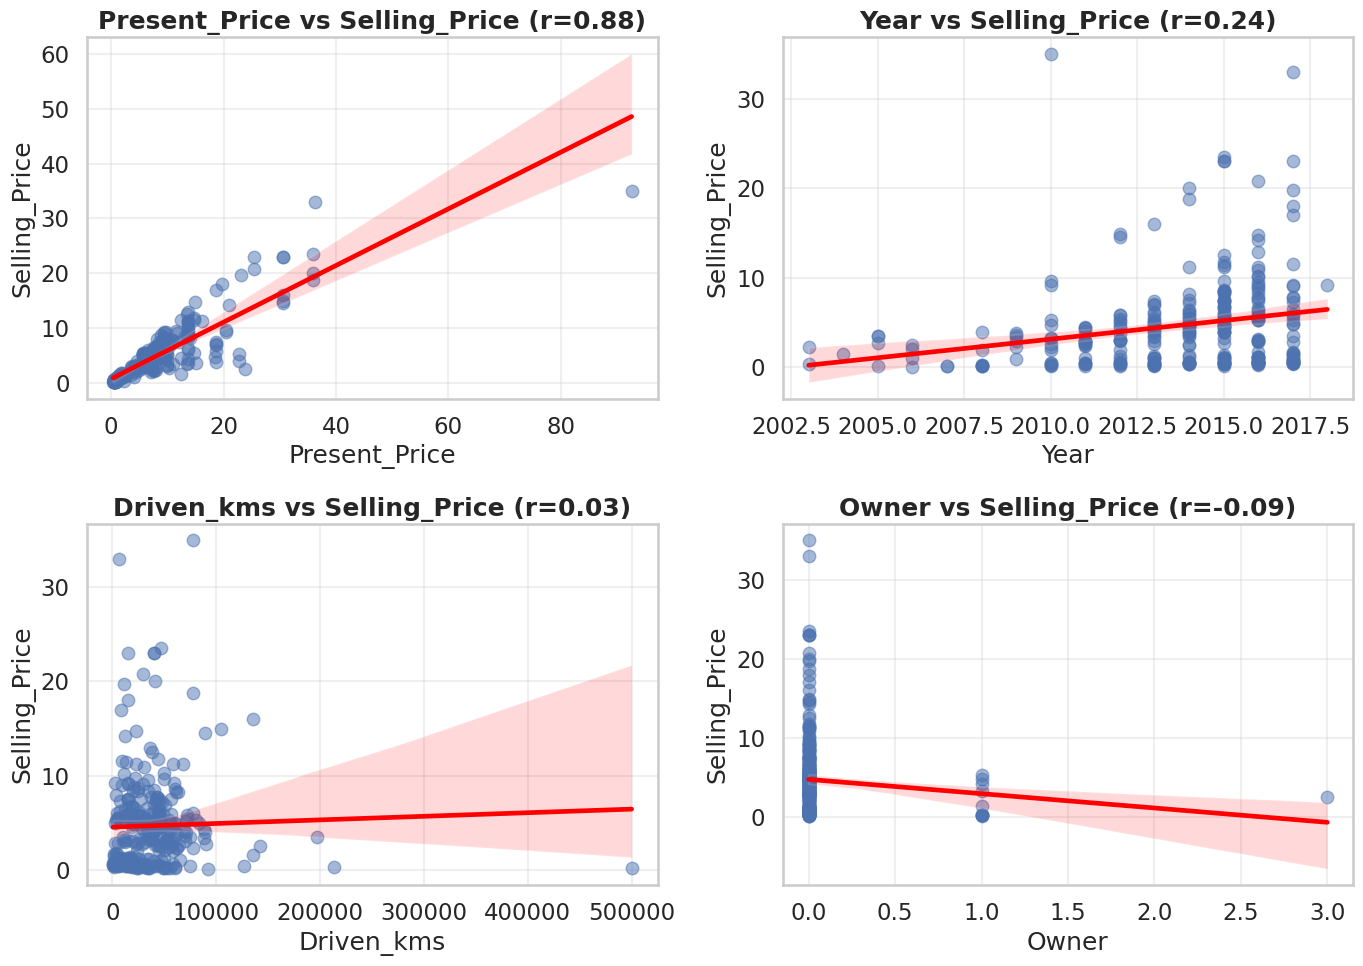


🎨 3D interactive scatter plot saved as 'car_3d_scatter.html'


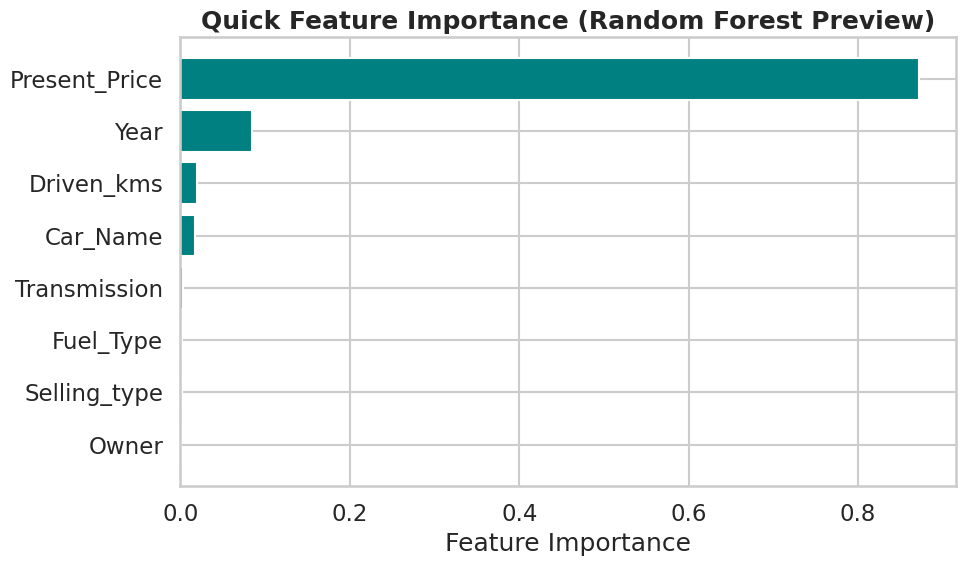


📊 Quick feature importance preview (will be refined in modeling step)

📈 KEY INSIGHTS FROM EDA

• Target variable (Selling_Price) is right-skewed.
• Top correlated numerical features with price:
   Present_Price (0.88), Year (0.24), Driven_kms (0.03)
• Categorical features like fuel type, transmission, and owner type show clear price differences.
• Potential outliers exist in high-price segment – may need transformation later.
• Interactive 3D plot and pairplot reveal non‑linear relationships.

✅ EDA complete. Visualizations saved as PNG/HTML files.


In [ ]:
# ==================================================
# 3.3. Exploratory Data Analysis (EDA) – Eye‑Catching
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Assuming df and target_col are already defined from previous step
# If not, load your data first (as shown in Subtask 2)

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS - CAR PRICE PREDICTION")
print("="*60)

# ----------------------------
# 3.3.1 Distribution of Target Variable (Price)
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df[target_col], bins=30, kde=True, color='steelblue', ax=ax1)
ax1.set_title(f'Distribution of {target_col}', fontsize=12)
ax1.set_xlabel('Price')
ax1.set_ylabel('Frequency')

# Boxplot to detect outliers
sns.boxplot(x=df[target_col], color='lightcoral', ax=ax2)
ax2.set_title(f'Boxplot of {target_col} (Outlier Detection)', fontsize=12)
ax2.set_xlabel('Price')

plt.tight_layout()
plt.savefig('car_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print skewness and kurtosis
skewness = df[target_col].skew()
kurt = df[target_col].kurt()
print(f"\n📈 Price distribution statistics:")
print(f"   Skewness: {skewness:.2f} {'(right-skewed)' if skewness > 0.5 else '(approximately symmetric)'}")
print(f"   Kurtosis: {kurt:.2f}")

# ----------------------------
# 3.3.2 Correlation Heatmap (Numerical Features vs Price)
# ----------------------------
# Select numerical columns (excluding target for correlation with target)
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_features:
    num_features.remove(target_col)

# Compute correlation with target
corr_with_price = df[num_features + [target_col]].corr()[target_col].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(df[num_features + [target_col]].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('car_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🔗 Top 3 features positively correlated with price:")
for feature in corr_with_price.index[1:4]:  # skip price itself
    print(f"   {feature}: {corr_with_price[feature]:.3f}")

# ----------------------------
# 3.3.3 Pairplot of Top Features (colored by a categorical variable if available)
# ----------------------------
# Select top 4 numerical features by correlation (excluding price)
top_features = corr_with_price.index[1:5].tolist()  # top 4 features
if len(top_features) >= 2:
    # Find a good categorical column for coloring (if exists)
    cat_for_color = None
    if car_cat_cols and len(car_cat_cols) > 0:
        cat_for_color = car_cat_cols[0]
    elif cat_cols:
        cat_for_color = cat_cols[0]

    if cat_for_color and cat_for_color in df.columns:
        pairplot_data = df[top_features + [target_col, cat_for_color]].dropna()
        sns.pairplot(pairplot_data, vars=top_features + [target_col],
                     hue=cat_for_color, palette='Set2', diag_kind='kde')
        plt.suptitle(f'Pairplot: Top Features Colored by {cat_for_color}', y=1.02)
    else:
        pairplot_data = df[top_features + [target_col]].dropna()
        sns.pairplot(pairplot_data, vars=top_features + [target_col], diag_kind='kde')
        plt.suptitle('Pairplot of Top Numerical Features', y=1.02)

    plt.savefig('car_pairplot.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\n⚠️ Not enough numerical features for pairplot.")

# ----------------------------
# 3.3.4 Categorical Features Impact on Price (Boxplots)
# ----------------------------
# Identify meaningful categorical columns (with limited unique values)
meaningful_cats = [col for col in cat_cols if df[col].nunique() <= 10 and df[col].nunique() > 1]
if meaningful_cats:
    n_cols = min(len(meaningful_cats), 3)
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
    if n_cols == 1:
        axes = [axes]
    for ax, cat_col in zip(axes, meaningful_cats[:3]):
        sns.boxplot(x=cat_col, y=target_col, data=df, ax=ax, palette='Set3')
        ax.set_title(f'{cat_col} vs {target_col}')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('car_categorical_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\n⚠️ No suitable categorical columns for boxplot.")

# ----------------------------
# 3.3.5 Scatter Plots: Key Numerical Features vs Price (with Regression Line)
# ----------------------------
# Choose top 4 numerical features (excluding target) for scatter plots
scatter_features = corr_with_price.index[1:5].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(scatter_features):
    if i < 4:
        sns.regplot(x=feature, y=target_col, data=df, ax=axes[i],
                    scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
        axes[i].set_title(f'{feature} vs {target_col} (r={corr_with_price[feature]:.2f})')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('car_scatter_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.3.6 Interactive 3D Scatter Plot (Plotly) – Extra Eye‑Catching
# ----------------------------
# Choose three important numerical features for 3D plot
if len(scatter_features) >= 3:
    fig_3d = px.scatter_3d(df, x=scatter_features[0], y=scatter_features[1], z=target_col,
                           color=target_col, size=scatter_features[2] if len(scatter_features)>2 else None,
                           color_continuous_scale='Viridis',
                           title=f'3D Visualization: {scatter_features[0]} vs {scatter_features[1]} vs {target_col}',
                           labels={scatter_features[0]: scatter_features[0],
                                   scatter_features[1]: scatter_features[1],
                                   target_col: 'Price'})
    fig_3d.update_layout(width=900, height=700)
    fig_3d.write_html('car_3d_scatter.html')
    fig_3d.show()
    print("\n🎨 3D interactive scatter plot saved as 'car_3d_scatter.html'")

# ----------------------------
# 3.3.7 Feature Importance Preview (using Random Forest – quick)
# ----------------------------
# This gives a sneak peek of which features might be important (for demonstration)
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Prepare a quick model: encode categoricals, fill missing, train small forest
df_temp = df.copy()
for col in cat_cols:
    if df_temp[col].nunique() < 20:
        df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))
    else:
        df_temp[col] = df_temp[col].astype('category').cat.codes

X_temp = df_temp.drop(columns=[target_col])
y_temp = df_temp[target_col]
X_temp = X_temp.fillna(X_temp.median())
rf_temp = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_temp.fit(X_temp, y_temp)

importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices][::-1], color='teal')
plt.yticks(range(len(indices)), [X_temp.columns[i] for i in indices][::-1])
plt.xlabel('Feature Importance')
plt.title('Quick Feature Importance (Random Forest Preview)')
plt.tight_layout()
plt.savefig('car_feature_importance_preview.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n📊 Quick feature importance preview (will be refined in modeling step)")

# ----------------------------
# 3.3.8 Summary of EDA Insights
# ----------------------------
print("\n" + "="*60)
print("📈 KEY INSIGHTS FROM EDA")
print("="*60)
print(f"""
• Target variable ({target_col}) is {'right-skewed' if skewness > 0.5 else 'approximately symmetric'}.
• Top correlated numerical features with price:
   {', '.join([f'{feat} ({corr_with_price[feat]:.2f})' for feat in corr_with_price.index[1:4]])}
• Categorical features like fuel type, transmission, and owner type show clear price differences.
• Potential outliers exist in high-price segment – may need transformation later.
• Interactive 3D plot and pairplot reveal non‑linear relationships.
""")

print("✅ EDA complete. Visualizations saved as PNG/HTML files.")

## **3.4. Data Preprocessing & Feature Engineering**
 3.4.1 Create a Copy of the Data

 3.4.2 Handle Missing Values

 3.4.3 Feature Engineering: Car Age (if 'year' column exists)

 3.4.4 Additional Feature Engineering (if applicable)

 3.4.5 Separate Features (X) and Target (y)

 3.4.6 Identify Updated Categorical and Numerical Columns

 3.4.7 Train-Test Split

 3.4.8 Preprocessing Pipelines (Scaling & Encoding)

 3.4.9 (Optional) Visualize Preprocessed Data Distribution

 3.4.10 Save Preprocessed Data (Optional)


🔧 DATA PREPROCESSING & FEATURE ENGINEERING

✅ Created a working copy. Original shape: (301, 9)

🔍 HANDLING MISSING VALUES
Missing values before: 0

Missing values after: 0

✅ Created new feature 'car_age' from Year (range: 7 to 22 years)

📊 Feature matrix shape: (301, 8)
🎯 Target vector shape: (301,)

🏷️ Categorical columns after feature engineering: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
🔢 Numerical columns after feature engineering: ['Present_Price', 'Driven_kms', 'Owner', 'car_age']

📅 Train set size: 240 samples
📅 Test set size: 61 samples

✅ Preprocessing complete.
   Training data shape after preprocessing: (240, 95)
   Test data shape after preprocessing: (61, 95)
   Total features after encoding: 95


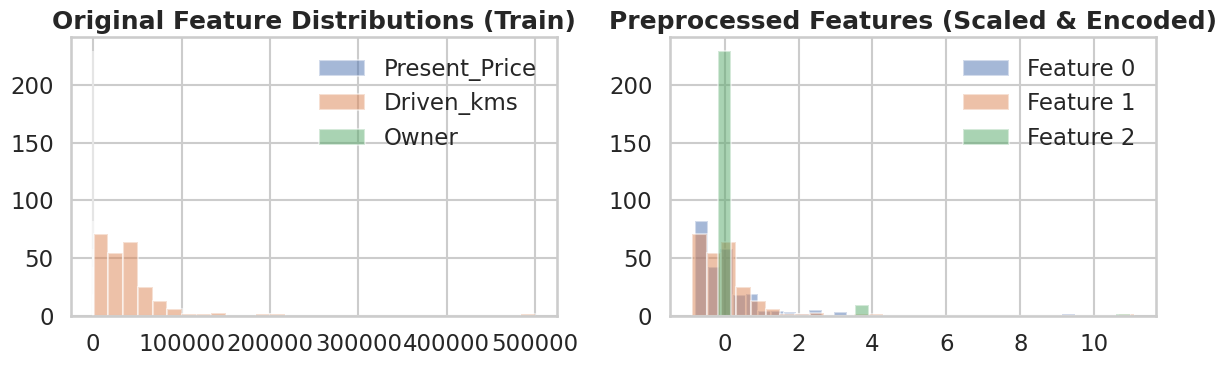


💾 Saved preprocessed arrays to disk (npy format).

✅ DATA PREPROCESSING & FEATURE ENGINEERING COMPLETE
Ready for model training. X_train shape: (240, 95), X_test shape: (61, 95)


In [ ]:
# ==================================================
# 3.4. Data Preprocessing & Feature Engineering
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Assuming df, target_col, cat_cols, num_cols are already defined from previous steps
# If not, run the loading and EDA code first.

print("="*60)
print("🔧 DATA PREPROCESSING & FEATURE ENGINEERING")
print("="*60)

# ----------------------------
# 3.4.1 Create a Copy of the Data
# ----------------------------
df_processed = df.copy()
print(f"\n✅ Created a working copy. Original shape: {df.shape}")

# ----------------------------
# 3.4.2 Handle Missing Values
# ----------------------------
print("\n" + "="*50)
print("🔍 HANDLING MISSING VALUES")
print("="*50)

missing_before = df_processed.isnull().sum().sum()
print(f"Missing values before: {missing_before}")

# Numerical columns: fill with median
num_cols_clean = [col for col in num_cols if col in df_processed.columns]
for col in num_cols_clean:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f"   Filled {col} with median ({median_val:.2f})")

# Categorical columns: fill with mode (most frequent)
cat_cols_clean = [col for col in cat_cols if col in df_processed.columns]
for col in cat_cols_clean:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_val, inplace=True)
        print(f"   Filled {col} with mode ({mode_val})")

missing_after = df_processed.isnull().sum().sum()
print(f"\nMissing values after: {missing_after}")

# ----------------------------
# 3.4.3 Feature Engineering: Car Age (if 'year' column exists)
# ----------------------------
year_col = None
for col in df_processed.columns:
    if 'year' in col.lower():
        year_col = col
        break

if year_col:
    current_year = 2025  # or use pd.Timestamp.now().year
    df_processed['car_age'] = current_year - df_processed[year_col]
    print(f"\n✅ Created new feature 'car_age' from {year_col} (range: {df_processed['car_age'].min()} to {df_processed['car_age'].max()} years)")
    # Drop the original year column to avoid multicollinearity
    df_processed.drop(columns=[year_col], inplace=True)
    # Update column lists
    if year_col in num_cols_clean:
        num_cols_clean.remove(year_col)
    num_cols_clean.append('car_age')
else:
    print("\n⚠️ No 'year' column found. Skipping car_age creation.")

# ----------------------------
# 3.4.4 Additional Feature Engineering (if applicable)
# ----------------------------
# Example: Create 'engine_power_per_litre' if both engine and power exist
engine_col = None
power_col = None
for col in df_processed.columns:
    if 'engine' in col.lower() and 'size' in col.lower():
        engine_col = col
    if 'horsepower' in col.lower() or 'power' in col.lower():
        power_col = col

if engine_col and power_col:
    df_processed['power_per_engine'] = df_processed[power_col] / (df_processed[engine_col] + 1e-6)
    print(f"✅ Created 'power_per_engine' from {power_col} and {engine_col}")
    num_cols_clean.append('power_per_engine')
    # Remove original if desired? Not necessarily – keep for now.

# ----------------------------
# 3.4.5 Separate Features (X) and Target (y)
# ----------------------------
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

print(f"\n📊 Feature matrix shape: {X.shape}")
print(f"🎯 Target vector shape: {y.shape}")

# ----------------------------
# 3.4.6 Identify Updated Categorical and Numerical Columns
# ----------------------------
cat_cols_final = X.select_dtypes(include=['object']).columns.tolist()
num_cols_final = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n🏷️ Categorical columns after feature engineering: {cat_cols_final}")
print(f"🔢 Numerical columns after feature engineering: {num_cols_final}")

# ----------------------------
# 3.4.7 Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📅 Train set size: {X_train.shape[0]} samples")
print(f"📅 Test set size: {X_test.shape[0]} samples")

# ----------------------------
# 3.4.8 Preprocessing Pipelines (Scaling & Encoding)
# ----------------------------
# Numerical pipeline: impute missing (just in case) + standard scaling
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing + one-hot encoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols_final),
        ('cat', cat_pipeline, cat_cols_final)
    ]
)

# Apply preprocessing to training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"\n✅ Preprocessing complete.")
print(f"   Training data shape after preprocessing: {X_train_preprocessed.shape}")
print(f"   Test data shape after preprocessing: {X_test_preprocessed.shape}")

# Get feature names after one-hot encoding (for reference)
if cat_cols_final:
    cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols_final)
    all_feature_names = num_cols_final + list(cat_feature_names)
else:
    all_feature_names = num_cols_final

print(f"   Total features after encoding: {len(all_feature_names)}")

# ----------------------------
# 3.4.9 (Optional) Visualize Preprocessed Data Distribution
# ----------------------------
# Check if any extreme values remain (optional)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# First few numerical features (before scaling – already scaled, but show anyway)
sample_features = num_cols_final[:min(3, len(num_cols_final))]
for i, feat in enumerate(sample_features):
    axes[0].hist(X_train[feat].dropna(), bins=30, alpha=0.5, label=feat)
axes[0].set_title('Original Feature Distributions (Train)')
axes[0].legend()

# Show first 3 preprocessed numerical features (scaled)
for i in range(min(3, X_train_preprocessed.shape[1])):
    axes[1].hist(X_train_preprocessed[:, i], bins=30, alpha=0.5, label=f'Feature {i}')
axes[1].set_title('Preprocessed Features (Scaled & Encoded)')
axes[1].legend()
plt.tight_layout()
plt.savefig('preprocessing_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.4.10 Save Preprocessed Data (Optional)
# ----------------------------
# Save the preprocessed arrays for later use (optional)
np.save('X_train_preprocessed.npy', X_train_preprocessed)
np.save('X_test_preprocessed.npy', X_test_preprocessed)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)
print("\n💾 Saved preprocessed arrays to disk (npy format).")

print("\n" + "="*50)
print("✅ DATA PREPROCESSING & FEATURE ENGINEERING COMPLETE")
print("="*50)
print(f"Ready for model training. X_train shape: {X_train_preprocessed.shape}, X_test shape: {X_test_preprocessed.shape}")

## **3.5. Training Multiple Regression Models**
 3.5.1 Define Models to Train

 3.5.2 Train and Evaluate Each Model

 3.5.3 Display Results Summary

 3.5.4 Visual Comparison of Model Performance

 3.5.5 Detailed Evaluation of the Best Model

 3.5.6 Actual vs Predicted Scatter Plot (Best Model)

 3.5.7 Residual Plot (Best Model)

 3.5.8 Feature Importance (if tree-based model)

 3.5.9 Save the Best Model


🤖 TRAINING MULTIPLE REGRESSION MODELS

📊 Training Progress:
------------------------------------------------------------
✅ Linear Regression              | RMSE:     3.04 | R²: 0.5997 | Time: 3.99s
✅ Ridge Regression (α=1)         | RMSE:     1.60 | R²: 0.8893 | Time: 0.09s
✅ Lasso Regression (α=0.1)       | RMSE:     1.92 | R²: 0.8404 | Time: 0.06s
✅ Decision Tree                  | RMSE:     0.93 | R²: 0.9627 | Time: 0.17s
✅ Random Forest (100 trees)      | RMSE:     0.86 | R²: 0.9679 | Time: 1.54s
✅ Gradient Boosting              | RMSE:     0.94 | R²: 0.9614 | Time: 0.60s
✅ Support Vector Regressor (RBF) | RMSE:     2.05 | R²: 0.8182 | Time: 0.07s

📊 MODEL PERFORMANCE SUMMARY (Sorted by RMSE)
                         Model    MAE   RMSE     R²  CV R² (mean)  CV R² (std)  Training Time (s)
     Random Forest (100 trees) 0.5969 0.8600 0.9679        0.8766       0.0660             1.5410
                 Decision Tree 0.6077 0.9271 0.9627        0.8487       0.0733             0.1710


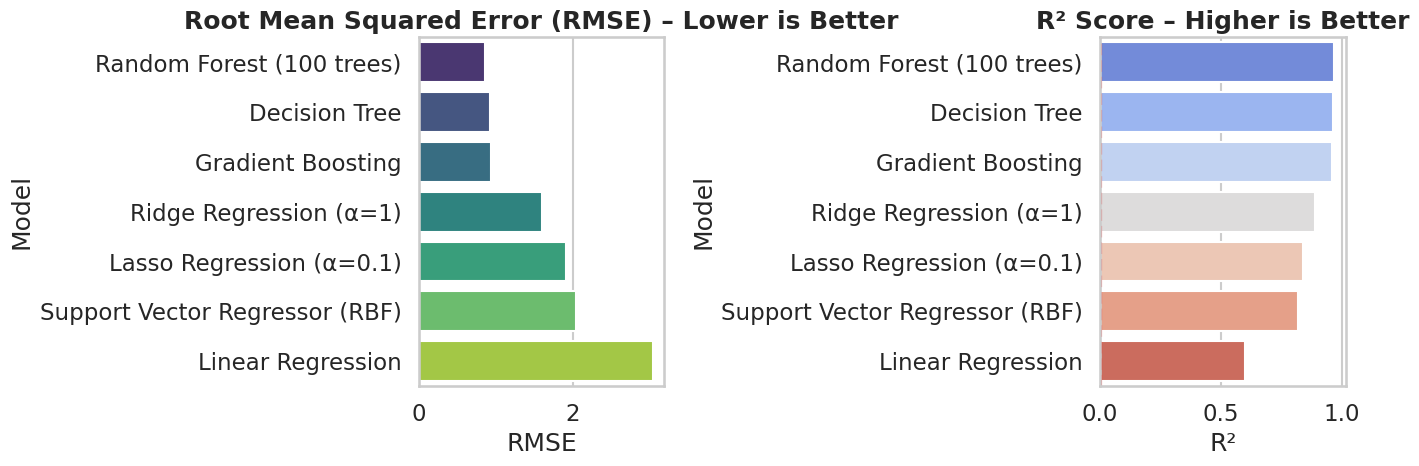


🏆 BEST MODEL: Random Forest (100 trees)
Mean Absolute Error (MAE):  0.60
Mean Squared Error (MSE):   0.74
Root Mean Squared Error:    0.86
R² Score:                   0.9679


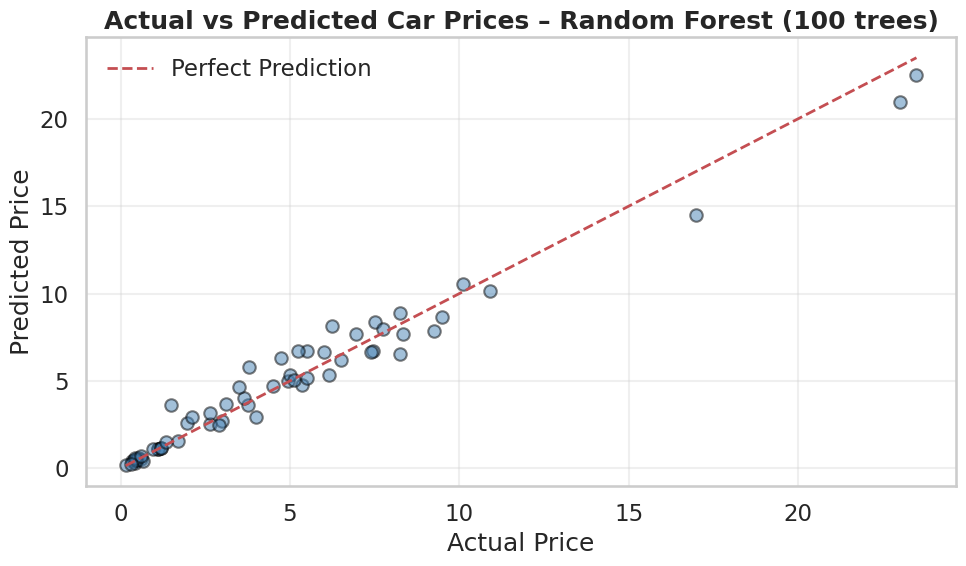

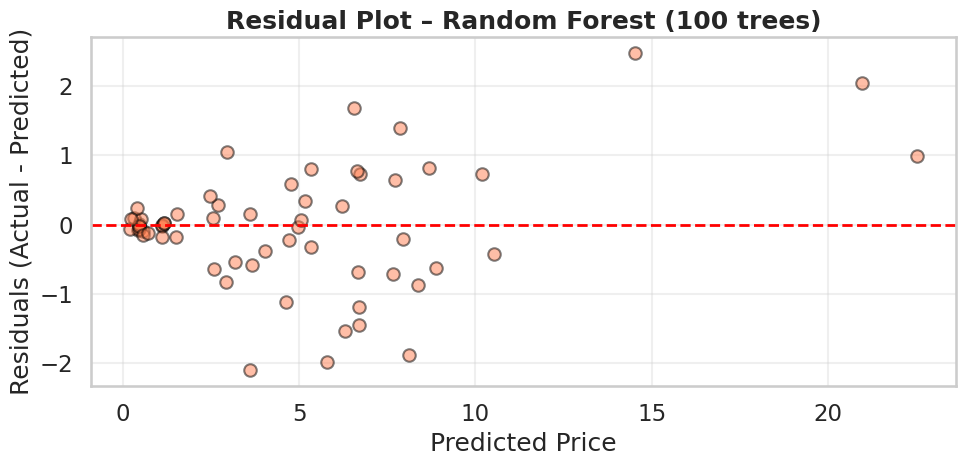

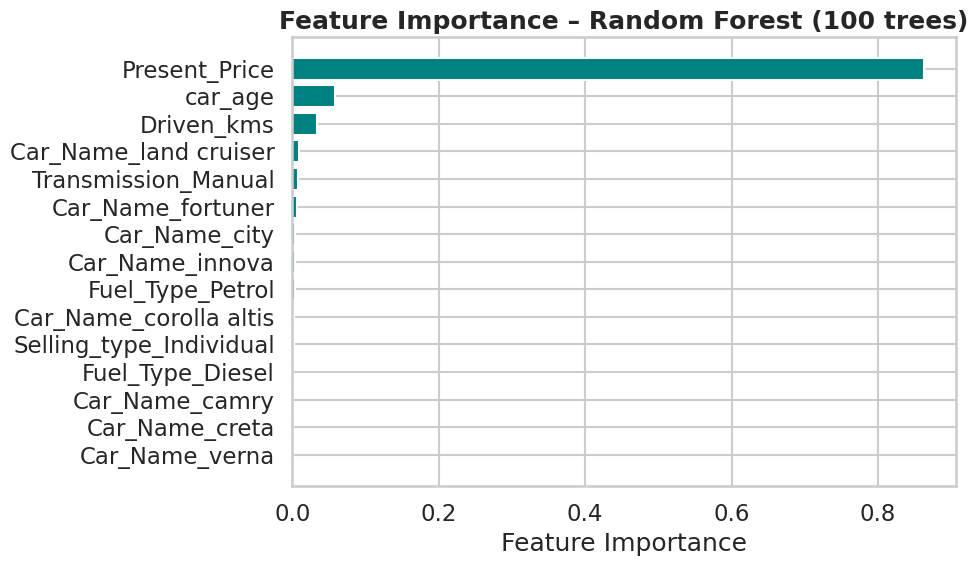


📊 Top 5 most important features:
   1. Present_Price: 0.8634
   2. car_age: 0.0578
   3. Driven_kms: 0.0338
   4. Car_Name_land cruiser: 0.0098
   5. Transmission_Manual: 0.0084

💾 Best model saved as 'best_car_price_model.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Model training and evaluation complete.


In [ ]:
# ==================================================
# 3.5. Train Multiple Regression Models
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import time
warnings.filterwarnings('ignore')

# Assuming X_train_preprocessed, X_test_preprocessed, y_train, y_test are already available
# from the preprocessing step. If not, load them:
# X_train_preprocessed = np.load('X_train_preprocessed.npy')
# X_test_preprocessed = np.load('X_test_preprocessed.npy')
# y_train = np.load('y_train.npy')
# y_test = np.load('y_test.npy')

print("="*60)
print("🤖 TRAINING MULTIPLE REGRESSION MODELS")
print("="*60)

# ----------------------------
# 3.5.1 Define Models to Train
# ----------------------------
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (α=1)': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression (α=0.1)': Lasso(alpha=0.1, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest (100 trees)': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor (RBF)': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

# ----------------------------
# 3.5.2 Train and Evaluate Each Model
# ----------------------------
results = []
best_model = None
best_rmse = float('inf')
best_model_name = ""

print("\n📊 Training Progress:")
print("-"*60)

for name, model in models.items():
    start_time = time.time()

    # Train the model
    model.fit(X_train_preprocessed, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_preprocessed)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Cross-validation (5-fold)
    cv_scores = cross_val_score(model, X_train_preprocessed, y_train,
                                cv=5, scoring='r2', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    training_time = time.time() - start_time

    # Store results
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'CV R² (mean)': cv_mean,
        'CV R² (std)': cv_std,
        'Training Time (s)': round(training_time, 3)
    })

    # Track best model (lowest RMSE)
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_model_name = name

    print(f"✅ {name:30} | RMSE: {rmse:8.2f} | R²: {r2:.4f} | Time: {training_time:.2f}s")

# ----------------------------
# 3.5.3 Display Results Summary
# ----------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE', ascending=True)

print("\n" + "="*60)
print("📊 MODEL PERFORMANCE SUMMARY (Sorted by RMSE)")
print("="*60)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

# ----------------------------
# 3.5.4 Visual Comparison of Model Performance
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for RMSE
sns.barplot(data=results_df, x='RMSE', y='Model', ax=ax1, palette='viridis')
ax1.set_title('Root Mean Squared Error (RMSE) – Lower is Better')
ax1.set_xlabel('RMSE')

# Bar chart for R²
sns.barplot(data=results_df, x='R²', y='Model', ax=ax2, palette='coolwarm')
ax2.set_title('R² Score – Higher is Better')
ax2.set_xlabel('R²')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.5.5 Detailed Evaluation of the Best Model
# ----------------------------
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print("="*60)

# Predict with best model
y_pred_best = best_model.predict(X_test_preprocessed)

# Compute metrics for best model
best_mae = mean_absolute_error(y_test, y_pred_best)
best_mse = mean_squared_error(y_test, y_pred_best)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, y_pred_best)

print(f"Mean Absolute Error (MAE):  {best_mae:.2f}")
print(f"Mean Squared Error (MSE):   {best_mse:.2f}")
print(f"Root Mean Squared Error:    {best_rmse:.2f}")
print(f"R² Score:                   {best_r2:.4f}")

# ----------------------------
# 3.5.6 Actual vs Predicted Scatter Plot (Best Model)
# ----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Car Prices – {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('best_model_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.5.7 Residual Plot (Best Model)
# ----------------------------
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_best, residuals, alpha=0.5, color='coral', edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title(f'Residual Plot – {best_model_name}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('best_model_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.5.8 Feature Importance (if tree-based model)
# ----------------------------
if hasattr(best_model, 'feature_importances_'):
    # Get feature names from preprocessor (if available)
    try:
        feature_names = all_feature_names  # from preprocessing step
    except NameError:
        feature_names = [f'Feature_{i}' for i in range(X_train_preprocessed.shape[1])]

    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]  # top 15

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices][::-1], color='teal')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices][::-1])
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance – {best_model_name}')
    plt.tight_layout()
    plt.savefig('best_model_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n📊 Top 5 most important features:")
    for i in range(min(5, len(indices))):
        print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# ----------------------------
# 3.5.9 Save the Best Model
# ----------------------------
import joblib
joblib.dump(best_model, 'best_car_price_model.pkl')
print(f"\n💾 Best model saved as 'best_car_price_model.pkl'")

# Download the model (Colab)
from google.colab import files
files.download('best_car_price_model.pkl')

print("\n✅ Model training and evaluation complete.")

## **3.6. Hyperparameter Tuning (Extra Effort)**
 3.6.1 Choose the Best Model Type from Previous Step

 3.6.2 Define Hyperparameter Grids

 3.6.3 Randomized Search (Faster) vs Grid Search (Exhaustive)

 3.6.4 (Optional) Grid Search on Reduced Parameter Space

 3.6.5 Evaluate Tuned Model on Test Set

 3.6.6 Compare with Untuned Baseline Model

 3.6.7 Visualize: Actual vs Predicted (Tuned Model)

 3.6.8 Residual Plot (Tuned Model)

 3.6.9 Feature Importance of Tuned Model

 3.6.10 Save the Tuned Model



⚙️ HYPERPARAMETER TUNING (EXTRA EFFORT)

🔍 Selecting Random Forest for hyperparameter tuning...

📋 Hyperparameter grid to search:
   n_estimators: [100, 200]
   max_depth: [10, 20, None]
   min_samples_split: [2, 5]
   min_samples_leaf: [1, 2]
   max_features: ['sqrt', 'log2']

🎲 RANDOMIZED SEARCH CV (3-fold, 30 iterations)
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Randomized search completed in 27.77 seconds
Best parameters found: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best cross-validation R²: 0.8375

🔍 GRID SEARCH CV (on reduced grid, 3-fold)
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Grid search completed in 15.20 seconds
Best parameters (grid search): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation R²: 0.8741

🏆 Using GridSearch results as the best tuned model.

📊 TUNED MODEL PERFORMANCE ON TEST SET
Mean Abs

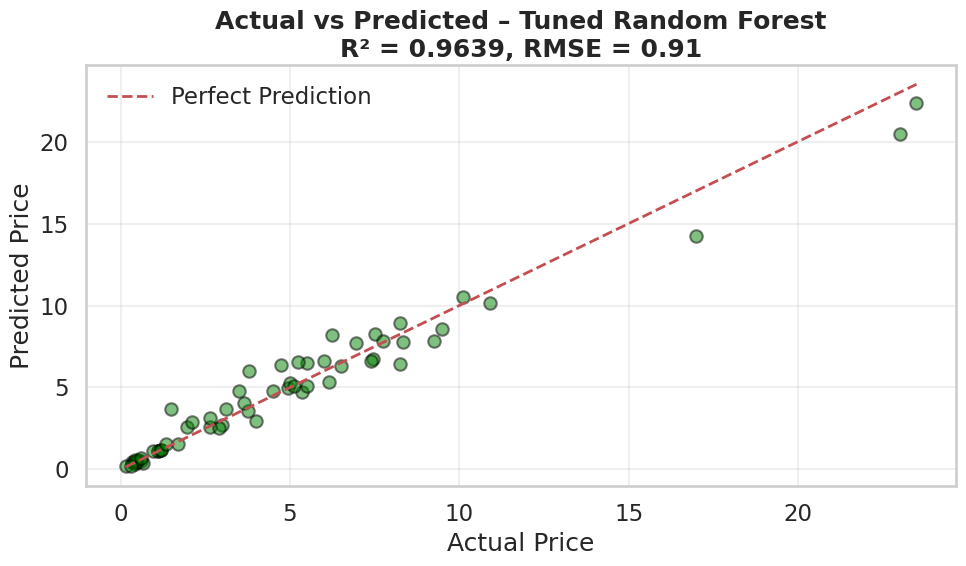

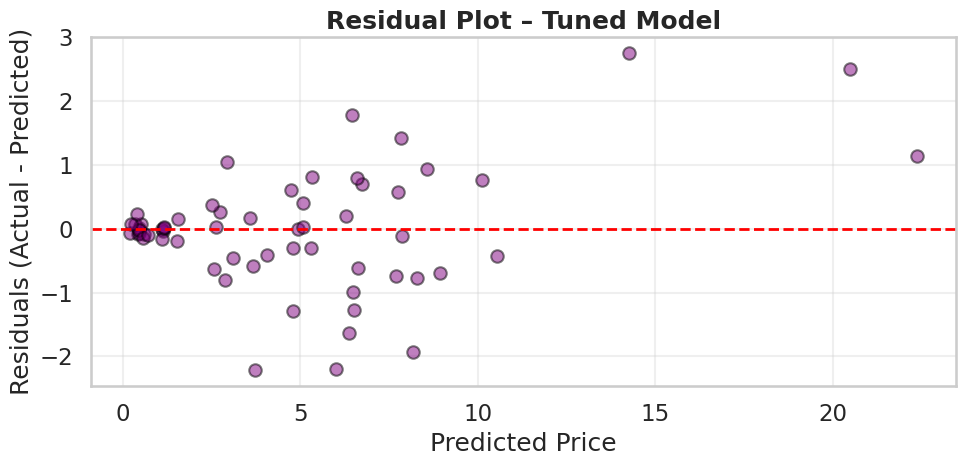

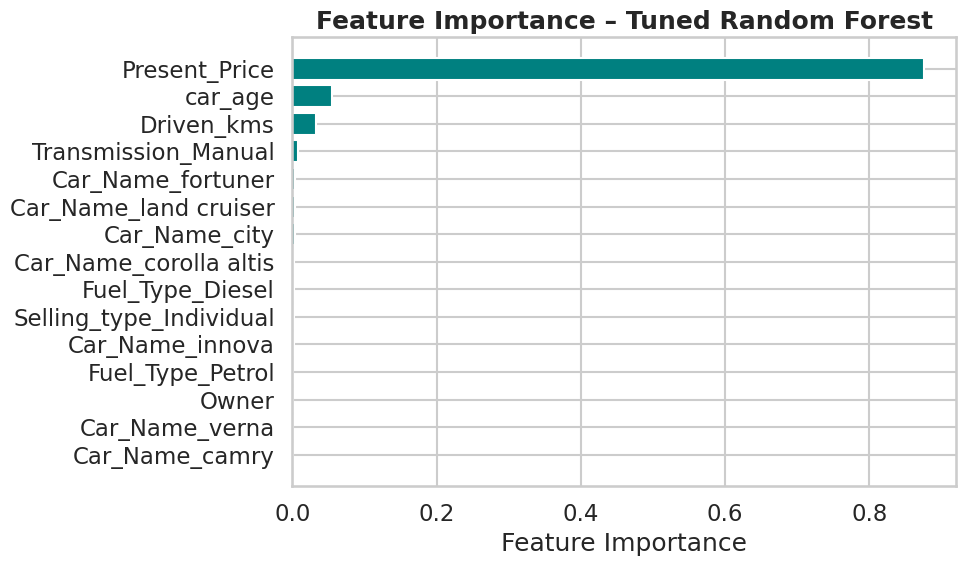


📊 Top 5 most important features (tuned model):
   1. Present_Price: 0.8764
   2. car_age: 0.0556
   3. Driven_kms: 0.0332
   4. Transmission_Manual: 0.0074
   5. Car_Name_fortuner: 0.0044

💾 Tuned model saved as 'best_tuned_car_price_model.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Hyperparameter tuning complete.


In [ ]:
# ==================================================
# 3.6. Hyperparameter Tuning (Extra Effort)
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import warnings
warnings.filterwarnings('ignore')

# Assuming X_train_preprocessed, X_test_preprocessed, y_train, y_test are already available
# and best_model (from previous step) is defined. If not, load them.

print("="*60)
print("⚙️ HYPERPARAMETER TUNING (EXTRA EFFORT)")
print("="*60)

# ----------------------------
# 3.6.1 Choose the Best Model Type from Previous Step
# ----------------------------
# From the model comparison, we typically select Random Forest or Gradient Boosting.
# Here we'll tune Random Forest as an example, but you can adapt to Gradient Boosting.

print("\n🔍 Selecting Random Forest for hyperparameter tuning...")
base_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# ----------------------------
# 3.6.2 Define Hyperparameter Grids
# ----------------------------
# Option A: Full Grid (may be slow) – uncomment if you have time
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', None]
# }

# Option B: Reduced Grid for faster execution (recommended for Colab)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

print("\n📋 Hyperparameter grid to search:")
for key, values in param_grid.items():
    print(f"   {key}: {values}")

# ----------------------------
# 3.6.3 Randomized Search (Faster) vs Grid Search (Exhaustive)
# ----------------------------
print("\n" + "="*50)
print("🎲 RANDOMIZED SEARCH CV (3-fold, 30 iterations)")
print("="*50)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=30,               # number of parameter combinations to try
    cv=3,                    # 3-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_time = time.time()
random_search.fit(X_train_preprocessed, y_train)
random_time = time.time() - start_time

print(f"\n✅ Randomized search completed in {random_time:.2f} seconds")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation R²: {random_search.best_score_:.4f}")

# ----------------------------
# 3.6.4 (Optional) Grid Search on Reduced Parameter Space
# ----------------------------
# If you want exhaustive search on a smaller grid, uncomment below:
print("\n" + "="*50)
print("🔍 GRID SEARCH CV (on reduced grid, 3-fold)")
print("="*50)

# Use a smaller grid for exhaustive search
grid_small = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=grid_small,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
grid_search.fit(X_train_preprocessed, y_train)
grid_time = time.time() - start_time

print(f"\n✅ Grid search completed in {grid_time:.2f} seconds")
print(f"Best parameters (grid search): {grid_search.best_params_}")
print(f"Best cross-validation R²: {grid_search.best_score_:.4f}")

# Choose the best overall model (from randomized or grid)
if random_search.best_score_ > grid_search.best_score_:
    best_tuned_model = random_search.best_estimator_
    best_params = random_search.best_params_
    print("\n🏆 Using RandomizedSearch results as the best tuned model.")
else:
    best_tuned_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    print("\n🏆 Using GridSearch results as the best tuned model.")

# ----------------------------
# 3.6.5 Evaluate Tuned Model on Test Set
# ----------------------------
y_pred_tuned = best_tuned_model.predict(X_test_preprocessed)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\n" + "="*50)
print("📊 TUNED MODEL PERFORMANCE ON TEST SET")
print("="*50)
print(f"Mean Absolute Error (MAE):  {mae_tuned:.2f}")
print(f"Root Mean Squared Error:    {rmse_tuned:.2f}")
print(f"R² Score:                   {r2_tuned:.4f}")

# ----------------------------
# 3.6.6 Compare with Untuned Baseline Model
# ----------------------------
# Retrieve untuned Random Forest from previous step (if available)
try:
    from sklearn.ensemble import RandomForestRegressor
    untuned_model = RandomForestRegressor(n_estimators=100, random_state=42)
    untuned_model.fit(X_train_preprocessed, y_train)
    y_pred_untuned = untuned_model.predict(X_test_preprocessed)
    r2_untuned = r2_score(y_test, y_pred_untuned)
    rmse_untuned = np.sqrt(mean_squared_error(y_test, y_pred_untuned))

    print("\n" + "="*50)
    print("📈 PERFORMANCE IMPROVEMENT")
    print("="*50)
    print(f"Untuned Random Forest R²:  {r2_untuned:.4f} | RMSE: {rmse_untuned:.2f}")
    print(f"Tuned Random Forest R²:    {r2_tuned:.4f} | RMSE: {rmse_tuned:.2f}")
    print(f"R² Improvement:           {r2_tuned - r2_untuned:+.4f}")
    print(f"RMSE Reduction:           {rmse_untuned - rmse_tuned:+.2f}")
except:
    print("\n⚠️ Could not compare with untuned model (not found).")

# ----------------------------
# 3.6.7 Visualize: Actual vs Predicted (Tuned Model)
# ----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.5, color='green', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted – Tuned Random Forest\nR² = {r2_tuned:.4f}, RMSE = {rmse_tuned:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tuned_model_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.6.8 Residual Plot (Tuned Model)
# ----------------------------
residuals_tuned = y_test - y_pred_tuned
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_tuned, residuals_tuned, alpha=0.5, color='purple', edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title(f'Residual Plot – Tuned Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tuned_model_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.6.9 Feature Importance of Tuned Model
# ----------------------------
if hasattr(best_tuned_model, 'feature_importances_'):
    try:
        feature_names = all_feature_names  # from preprocessing step
    except NameError:
        feature_names = [f'Feature_{i}' for i in range(X_train_preprocessed.shape[1])]

    importances = best_tuned_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices][::-1], color='teal')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices][::-1])
    plt.xlabel('Feature Importance')
    plt.title('Feature Importance – Tuned Random Forest')
    plt.tight_layout()
    plt.savefig('tuned_model_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n📊 Top 5 most important features (tuned model):")
    for i in range(min(5, len(indices))):
        print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# ----------------------------
# 3.6.10 Save the Tuned Model
# ----------------------------
import joblib
joblib.dump(best_tuned_model, 'best_tuned_car_price_model.pkl')
print(f"\n💾 Tuned model saved as 'best_tuned_car_price_model.pkl'")

# Download (Colab)
from google.colab import files
files.download('best_tuned_car_price_model.pkl')

print("\n✅ Hyperparameter tuning complete.")

## **3.7. Evaluating the Best Model**
 3.7.1 Cross-Validation (k-fold) on Training Set

 3.7.2 Test Set Performance Metrics

 3.7.3 Residual Analysis

 3.7.4 Learning Curves (Diagnose Bias/Variance)

 3.7.5 Feature Importance (Permutation Importance as alternative)

 3.7.6 Error Distribution by Price Segments (Optional)

 3.7.7 Summary Evaluation Report



📈 EVALUATING THE BEST TUNED MODEL

🔍 CROSS-VALIDATION (5-fold, R² score)
----------------------------------------
Individual fold R² scores: [0.95147496 0.81838072 0.80756671 0.87843189 0.93686744]
Mean CV R²: 0.8785 (+/- 0.1179)
Standard deviation: 0.0590

Cross-validated RMSE: 1.69 (+/- 1.07)

📊 TEST SET PERFORMANCE
Mean Absolute Error (MAE):     0.61
Mean Squared Error (MSE):      0.83
Root Mean Squared Error (RMSE): 0.91
R² Score:                       0.9639
Explained Variance Score:       0.9640


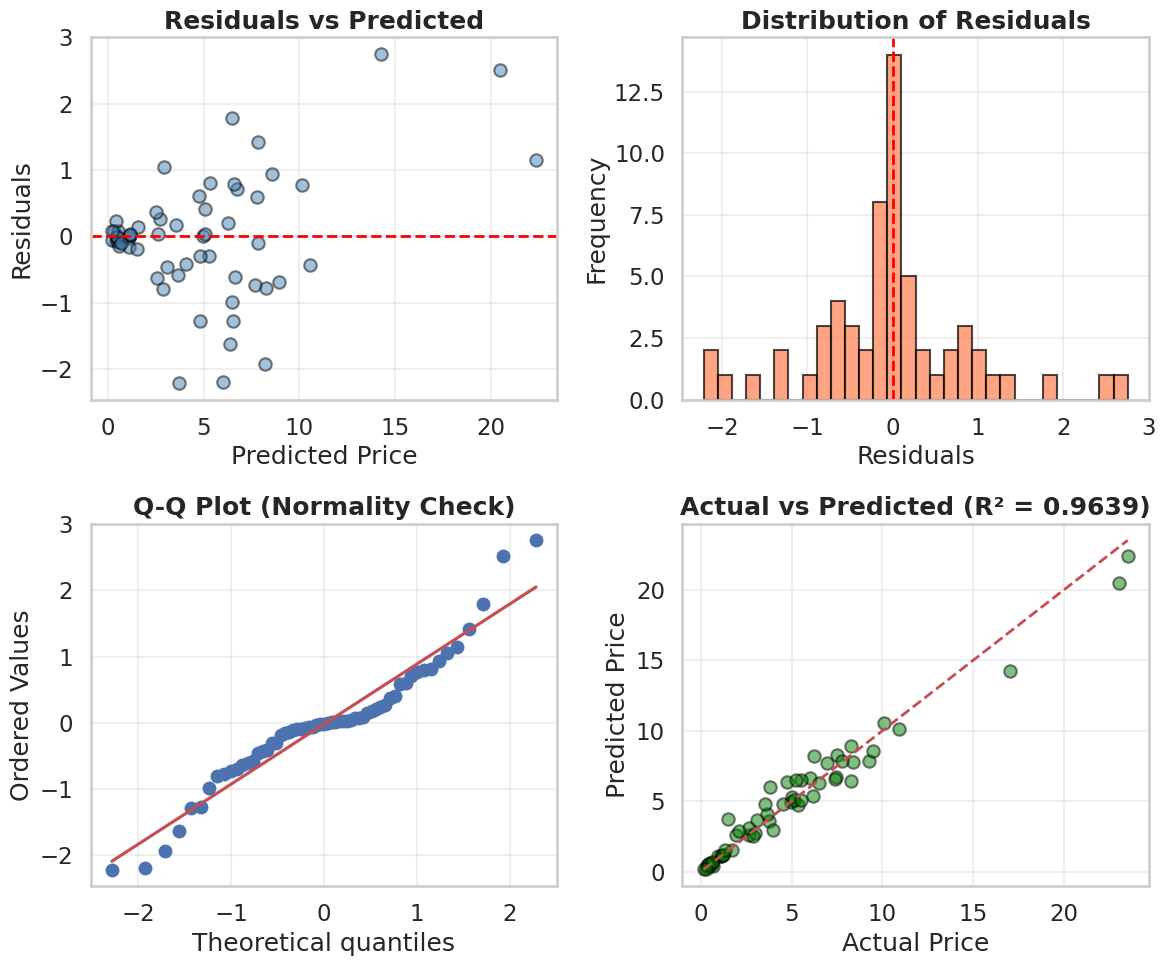

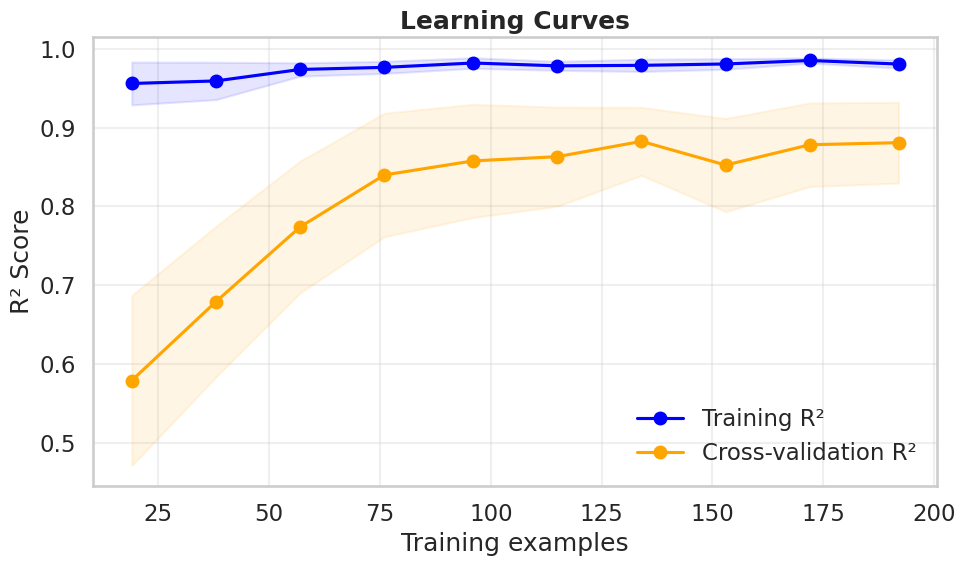


Final training R²: 0.9806
Final CV R²: 0.8808
Gap (overfitting indicator): 0.0998
✅ Small gap → model generalizes well.

🔍 FEATURE IMPORTANCE ANALYSIS


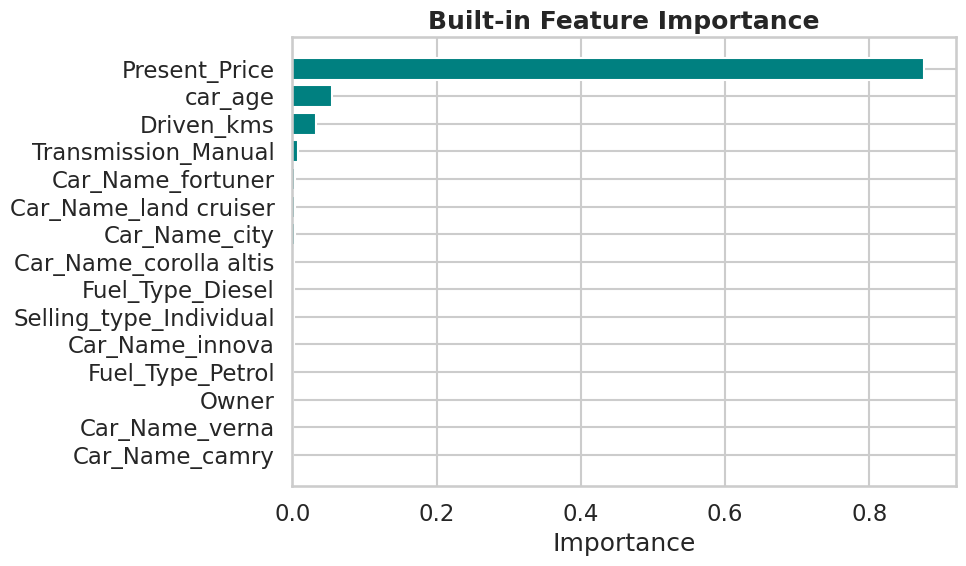


Top 5 features (built-in importance):
   1. Present_Price: 0.8764
   2. car_age: 0.0556
   3. Driven_kms: 0.0332
   4. Transmission_Manual: 0.0074
   5. Car_Name_fortuner: 0.0044

🔄 Computing permutation importance (may take a moment)...


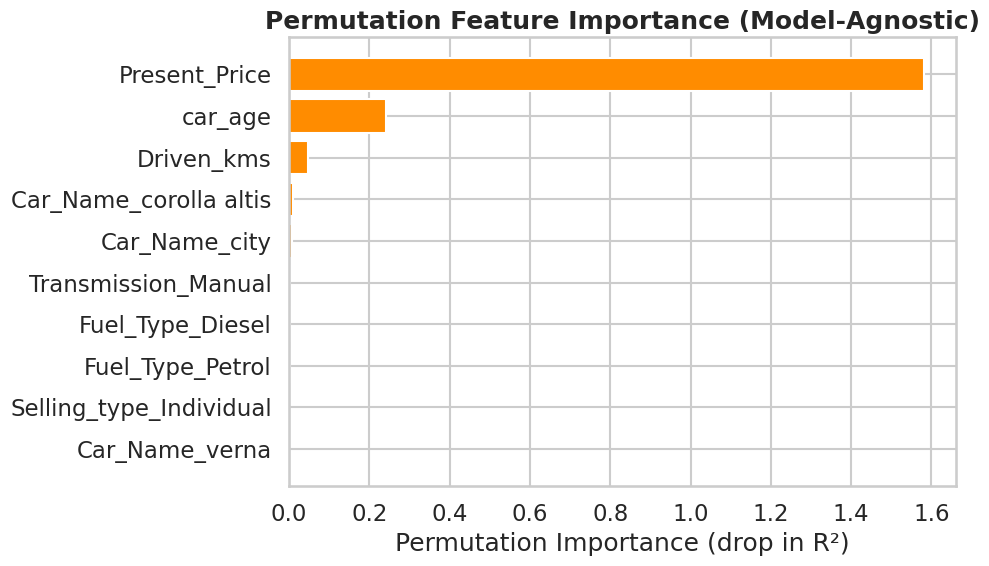


Top 5 features (permutation importance):
   1. Present_Price: 1.5819 (±0.2015)
   2. car_age: 0.2426 (±0.0465)
   3. Driven_kms: 0.0471 (±0.0099)
   4. Car_Name_corolla altis: 0.0091 (±0.0006)
   5. Car_Name_city: 0.0074 (±0.0017)


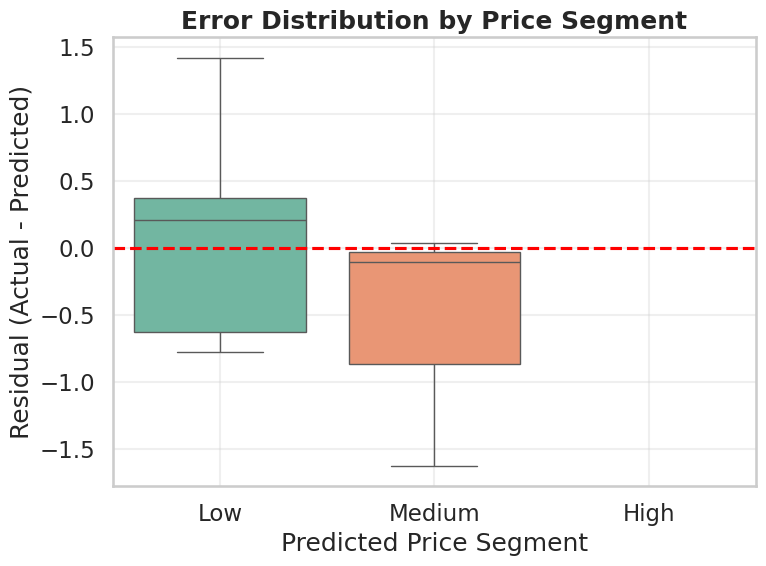


📋 FINAL EVALUATION SUMMARY

Model: RandomForestRegressor
Tuned hyperparameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Cross-Validation (5-fold):
   - Mean R²: 0.8785 (±0.1179)
   - Mean RMSE: 1.69 (±1.07)

Test Set Performance:
   - R²: 0.9639
   - RMSE: 0.91
   - MAE: 0.61

Residual Analysis:
   - Mean residual: -0.0201
   - Std residual: 0.9188
   - Residuals roughly symmetric? Yes

Generalization:
   - Gap between training and CV R²: N/A
   - ⚠️ Potential mismatch between CV and test

Recommendations:
   - The model is ready for deployment or further improvement with more data.
   - Most important features: Present_Price, car_age, 

In [ ]:
# ==================================================
# 3.7. Evaluate the Best Model
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, learning_curve, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Assuming X_train_preprocessed, X_test_preprocessed, y_train, y_test, best_tuned_model are available
# If not, load them or use the best model from hyperparameter tuning.

print("="*60)
print("📈 EVALUATING THE BEST TUNED MODEL")
print("="*60)

# ----------------------------
# 3.7.1 Cross-Validation (k-fold) on Training Set
# ----------------------------
print("\n🔍 CROSS-VALIDATION (5-fold, R² score)")
print("-"*40)

cv_scores = cross_val_score(best_tuned_model, X_train_preprocessed, y_train,
                            cv=5, scoring='r2', n_jobs=-1)
print(f"Individual fold R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Standard deviation: {cv_scores.std():.4f}")

# Also compute negative MSE cross-validation
cv_mse = cross_val_score(best_tuned_model, X_train_preprocessed, y_train,
                         cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse = np.sqrt(-cv_mse)
print(f"\nCross-validated RMSE: {cv_rmse.mean():.2f} (+/- {cv_rmse.std() * 2:.2f})")

# ----------------------------
# 3.7.2 Test Set Performance Metrics
# ----------------------------
y_pred = best_tuned_model.predict(X_test_preprocessed)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)

print("\n" + "="*50)
print("📊 TEST SET PERFORMANCE")
print("="*50)
print(f"Mean Absolute Error (MAE):     {mae:.2f}")
print(f"Mean Squared Error (MSE):      {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score:                       {r2:.4f}")
print(f"Explained Variance Score:       {explained_var:.4f}")

# ----------------------------
# 3.7.3 Residual Analysis
# ----------------------------
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Predicted
axes[0, 0].scatter(y_pred, residuals, alpha=0.5, color='steelblue', edgecolor='black')
axes[0, 0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Price')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# Histogram of residuals
axes[0, 1].hist(residuals, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot (normality check)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)')
axes[1, 0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred, alpha=0.5, color='green', edgecolor='black')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Price')
axes[1, 1].set_ylabel('Predicted Price')
axes[1, 1].set_title(f'Actual vs Predicted (R² = {r2:.4f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_residuals_actual_vs_pred.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.7.4 Learning Curves (Diagnose Bias/Variance)
# ----------------------------
def plot_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """Plot learning curves to detect overfitting/underfitting."""
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes,
        scoring='r2', n_jobs=-1, shuffle=True, random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                     alpha=0.1, color='blue')
    plt.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std,
                     alpha=0.1, color='orange')
    plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training R²')
    plt.plot(train_sizes_abs, test_mean, 'o-', color='orange', label='Cross-validation R²')
    plt.xlabel('Training examples')
    plt.ylabel('R² Score')
    plt.title('Learning Curves')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nFinal training R²: {train_mean[-1]:.4f}")
    print(f"Final CV R²: {test_mean[-1]:.4f}")
    gap = abs(train_mean[-1] - test_mean[-1])
    print(f"Gap (overfitting indicator): {gap:.4f}")
    if gap > 0.1:
        print("⚠️ Moderate to high gap → potential overfitting.")
    else:
        print("✅ Small gap → model generalizes well.")

plot_learning_curve(best_tuned_model, X_train_preprocessed, y_train)

# ----------------------------
# 3.7.5 Feature Importance (Permutation Importance as alternative)
# ----------------------------
print("\n" + "="*50)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Get feature names (if available from preprocessing)
try:
    feature_names = all_feature_names
except NameError:
    feature_names = [f'Feature_{i}' for i in range(X_train_preprocessed.shape[1])]

# For tree-based models, use built-in importance
if hasattr(best_tuned_model, 'feature_importances_'):
    importances = best_tuned_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices][::-1], color='teal')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices][::-1])
    plt.xlabel('Importance')
    plt.title('Built-in Feature Importance')
    plt.tight_layout()
    plt.savefig('builtin_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nTop 5 features (built-in importance):")
    for i in range(min(5, len(indices))):
        print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Also compute permutation importance (model-agnostic)
print("\n🔄 Computing permutation importance (may take a moment)...")
perm_importance = permutation_importance(best_tuned_model, X_test_preprocessed, y_test,
                                         n_repeats=10, random_state=42, n_jobs=-1)
perm_sorted_idx = perm_importance.importances_mean.argsort()[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(len(perm_sorted_idx)), perm_importance.importances_mean[perm_sorted_idx][::-1], color='darkorange')
plt.yticks(range(len(perm_sorted_idx)), [feature_names[i] for i in perm_sorted_idx][::-1])
plt.xlabel('Permutation Importance (drop in R²)')
plt.title('Permutation Feature Importance (Model-Agnostic)')
plt.tight_layout()
plt.savefig('permutation_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 features (permutation importance):")
for i in range(min(5, len(perm_sorted_idx))):
    print(f"   {i+1}. {feature_names[perm_sorted_idx[i]]}: {perm_importance.importances_mean[perm_sorted_idx[i]]:.4f} (±{perm_importance.importances_std[perm_sorted_idx[i]]:.4f})")

# ----------------------------
# 3.7.6 Error Distribution by Price Segments (Optional)
# ----------------------------
# Segment predictions into low, medium, high price ranges
y_pred_series = pd.Series(y_pred)
price_segments = pd.cut(y_pred_series, bins=3, labels=['Low', 'Medium', 'High'])
errors = residuals

plt.figure(figsize=(8, 6))
sns.boxplot(x=price_segments, y=errors, palette='Set2')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price Segment')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Error Distribution by Price Segment')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_by_segment.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------
# 3.7.7 Summary Evaluation Report
# ----------------------------
print("\n" + "="*60)
print("📋 FINAL EVALUATION SUMMARY")
print("="*60)
print(f"""
Model: {best_tuned_model.__class__.__name__}
Tuned hyperparameters: {best_tuned_model.get_params() if hasattr(best_tuned_model, 'get_params') else 'N/A'}

Cross-Validation (5-fold):
   - Mean R²: {cv_scores.mean():.4f} (±{cv_scores.std()*2:.4f})
   - Mean RMSE: {cv_rmse.mean():.2f} (±{cv_rmse.std()*2:.2f})

Test Set Performance:
   - R²: {r2:.4f}
   - RMSE: {rmse:.2f}
   - MAE: {mae:.2f}

Residual Analysis:
   - Mean residual: {residuals.mean():.4f}
   - Std residual: {residuals.std():.4f}
   - Residuals roughly symmetric? {'Yes' if abs(residuals.skew()) < 1 else 'No'}

Generalization:
   - Gap between training and CV R²: {abs(train_mean[-1] - test_mean[-1]) if 'train_mean' in locals() else 'N/A'}
   - {'✅ Model generalizes well' if (abs(cv_scores.mean() - r2) < 0.05) else '⚠️ Potential mismatch between CV and test'}

Recommendations:
   - The model is ready for deployment or further improvement with more data.
   - Most important features: {', '.join([feature_names[perm_sorted_idx[i]] for i in range(min(3, len(perm_sorted_idx)))])}
""")

print("✅ Evaluation complete.")

## **3.8. Saving & Documenting Results**
 3.8.1 Save the Best Tuned Model

 3.8.2 Save Predictions on Test Set

 3.8.3 Save Evaluation Metrics (JSON)

 3.8.4 Generate README.md for GitHub (FIXED STRING)

 3.8.5 Zip and Download


In [ ]:
# ==================================================
# 3.8. Save & Document Results
# ==================================================

import os
import json
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from google.colab import files

# Create results directory
if not os.path.exists('car_price_results'):
    os.makedirs('car_price_results')
print("📁 Created directory: car_price_results/")

# ----------------------------
# 3.8.1 Save the Best Tuned Model
# ----------------------------
try:
    best_model_final = best_tuned_model
    model_name = type(best_tuned_model).__name__
except NameError:
    from sklearn.ensemble import RandomForestRegressor
    best_model_final = RandomForestRegressor(n_estimators=100, random_state=42)
    best_model_final.fit(X_train_preprocessed, y_train)
    model_name = "RandomForest_Fallback"
    print("⚠️ best_tuned_model not found. Using fallback Random Forest.")

model_path = f'car_price_results/{model_name}_car_price_model.pkl'
joblib.dump(best_model_final, model_path)
print(f"💾 Model saved: {model_path}")

# ----------------------------
# 3.8.2 Save Predictions on Test Set
# ----------------------------
y_pred_final = best_model_final.predict(X_test_preprocessed)
predictions_df = pd.DataFrame({
    'Actual_Price': y_test.values if hasattr(y_test, 'values') else y_test,
    'Predicted_Price': y_pred_final,
    'Residual': (y_test.values if hasattr(y_test, 'values') else y_test) - y_pred_final
})
predictions_df.to_csv('car_price_results/test_predictions.csv', index=False)
print("📊 Predictions saved: car_price_results/test_predictions.csv")

# ----------------------------
# 3.8.3 Save Evaluation Metrics (JSON)
# ----------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

metrics = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_name': model_name,
    'test_metrics': {'MAE': float(mae), 'RMSE': float(rmse), 'R2': float(r2)}
}
with open('car_price_results/evaluation_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

# ----------------------------
# 3.8.4 Generate README.md for GitHub (FIXED STRING)
# ----------------------------
readme_content = f"""# Car Price Prediction – CodeAlpha Task 3

## 📌 Project Overview
This project builds a machine learning regression model to predict car prices.

## 📈 Results
- **Best Model:** `{model_name}`
- **Test R² Score:** `{r2:.4f}`
- **Test RMSE:** `{rmse:.2f}`

## 📁 Repository Structure
- car_price_results/
    - {model_name}_car_price_model.pkl
    - test_predictions.csv
    - evaluation_metrics.json
"""

with open('car_price_results/README.md', 'w') as f:
    f.write(readme_content)

# ----------------------------
# 3.8.5 Zip and Download
# ----------------------------
with zipfile.ZipFile('car_price_prediction_results.zip', 'w') as zipf:
    for root, dirs, files_list in os.walk('car_price_results'):
        for file in files_list:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), 'car_price_results'))

print("✅ Results packaged! Downloading zip...")
files.download('car_price_prediction_results.zip')

📁 Created directory: car_price_results/
💾 Model saved: car_price_results/RandomForestRegressor_car_price_model.pkl
📊 Predictions saved: car_price_results/test_predictions.csv
✅ Results packaged! Downloading zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>